 # EDA Notebook (Pandas-only) for 4 CSV tables



 **Goal:** perform a detailed exploratory data analysis (EDA) in pure Python (no DuckDB).



 **Tables**

 - `backend_events.csv`: events with `event_timestamp`, `user_id`, `organization_id`, `event_name`, and `event_properties` (stringified payload).

 - `hubspot_deals.csv`: HubSpot deals with amounts, stages timestamps, and `hubspot_company_id`.

 - `hubspot_companies.csv`: HubSpot companies keyed by `company_id`.

 - `hubspot_contacts.csv`: HubSpot contacts keyed by `contact_id` with `hubspot_company_id`.



 **Assumptions**

 - CSVs are in the repo root by default; change `DATA_DIR` if needed.

 - Time columns are parseable by pandas.

 - `event_properties` may be JSON; we will attempt safe parsing.

In [6]:
# Optional installs (uncomment if needed)
# !pip -q install pandas numpy matplotlib


In [7]:
from __future__ import annotations

from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 160)
pd.set_option("display.max_colwidth", 200)


 ## 0) Load data

In [8]:
REPO_ROOT = Path.cwd()
DATA_DIR = REPO_ROOT / "data"
print(f"Looking for CSV files in {DATA_DIR}...")
PATHS = {
    "backend_events": DATA_DIR / "backend_events.csv",
    "hubspot_deals": DATA_DIR / "hubspot_deals.csv",
    "hubspot_companies": DATA_DIR / "hubspot_companies.csv",
    "hubspot_contacts": DATA_DIR / "hubspot_contacts.csv",
}

missing = [str(p) for p in PATHS.values() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing CSV files:\n- " + "\n- ".join(missing) +
        "\n\nUpdate DATA_DIR or filenames."
    )


Looking for CSV files in /Users/vitalii/Desktop/unne/bi-technical-challenge/data...


In [9]:
# Dtypes: keep IDs as strings where appropriate to avoid loss of leading zeros (if any).
# You provided types; we follow them but keep flexibility for messy exports.
backend_dtypes = {
    "event_id": "string",
    "event_name": "string",
    "user_id": "string",
    "organization_id": "string",
    "event_properties": "string",
}
deals_dtypes = {
    "deal_id": "Int64",
    "deal_name": "string",
    "pipeline": "string",
    "is_closed": "boolean",
    "is_closed_won": "boolean",
    "amount": "Int64",
    "hubspot_company_id": "Int64",
    "deal_type": "string",
    "currency": "string",
}
org_dtypes = {
    "company_id": "Int64",
    "company_name": "string",
    "domain": "string",
    "industry": "string",
    "country": "string",
    "number_of_employees": "string",  # often messy; we will coerce later
}
contacts_dtypes = {
    "contact_id": "Int64",
    "first_name": "string",
    "last_name": "string",
    "email": "string",
    "job_title": "string",
    "hubspot_company_id": "Int64",
    "lifecycle_stage": "string",
}

# Parse datetime columns
backend_parse_dates = ["event_timestamp"]
deals_parse_dates = [
    "close_date",
    "create_date",
    "date_entered_pre_pitch",
    "date_entered_pitching",
    "date_entered_product_testing",
    "date_entered_price_offering",
    "date_entered_contract_negotiation",
    "date_entered_closed_won",
    "date_entered_closed_lost",
]
org_parse_dates = ["create_date"]
contacts_parse_dates = ["create_date"]


In [10]:
backend_events = pd.read_csv(PATHS["backend_events"], dtype=backend_dtypes, parse_dates=backend_parse_dates, low_memory=False)
hubspot_deals = pd.read_csv(PATHS["hubspot_deals"], dtype=deals_dtypes, parse_dates=deals_parse_dates, low_memory=False)
hubspot_companies = pd.read_csv(PATHS["hubspot_companies"], dtype=org_dtypes, parse_dates=org_parse_dates, low_memory=False)
hubspot_contacts = pd.read_csv(PATHS["hubspot_contacts"], dtype=contacts_dtypes, parse_dates=contacts_parse_dates, low_memory=False)

tables = {
    "backend_events": backend_events,
    "hubspot_deals": hubspot_deals,
    "hubspot_companies": hubspot_companies,
    "hubspot_contacts": hubspot_contacts,
}


In [11]:
# Quick shape + memory overview
overview = []
for name, df in tables.items():
    overview.append({
        "table": name,
        "rows": len(df),
        "cols": df.shape[1],
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024 / 1024, 2),
    })
pd.DataFrame(overview).sort_values("rows", ascending=False)


,table,rows,cols,memory_mb
0,backend_events,39206,6,22.20
3,hubspot_contacts,489,8,0.17
2,hubspot_companies,253,7,0.09
1,hubspot_deals,89,18,0.03


 ## 1) Schema, missing values, duplicates

In [12]:
def schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "non_null": [df[c].notna().sum() for c in df.columns],
        "nulls": [df[c].isna().sum() for c in df.columns],
        "null_pct": [round(df[c].isna().mean() * 100, 2) for c in df.columns],
        "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
    }).sort_values(["null_pct", "n_unique"], ascending=[False, True])


In [13]:
for name, df in tables.items():
    print(f"\n=== {name} ===")
    display(schema_summary(df))



=== backend_events ===


,column,dtype,non_null,nulls,null_pct,n_unique
1,event_name,string,39206,0,0.0,14
4,organization_id,string,39206,0,0.0,37
3,user_id,string,39206,0,0.0,150
5,event_properties,string,39206,0,0.0,27148
2,event_timestamp,datetime64[ns],39206,0,0.0,39144
0,event_id,string,39206,0,0.0,39206



=== hubspot_deals ===


,column,dtype,non_null,nulls,null_pct,n_unique
16,date_entered_closed_won,datetime64[ns],33,56,62.92,33
17,date_entered_closed_lost,datetime64[ns],37,52,58.43,37
15,date_entered_contract_negotiation,datetime64[ns],55,34,38.20,55
14,date_entered_price_offering,datetime64[ns],59,30,33.71,59
13,date_entered_product_testing,datetime64[ns],64,25,28.09,64
6,close_date,datetime64[ns],68,21,23.60,68
11,date_entered_pre_pitch,datetime64[ns],69,20,22.47,69
12,date_entered_pitching,datetime64[ns],75,14,15.73,75
2,pipeline,string,89,0,0.00,1
10,currency,string,89,0,0.00,1



=== hubspot_companies ===


,column,dtype,non_null,nulls,null_pct,n_unique
5,number_of_employees,string,253,0,0.0,6
4,country,string,253,0,0.0,17
3,industry,string,253,0,0.0,18
2,domain,string,253,0,0.0,238
1,company_name,string,253,0,0.0,249
0,company_id,Int64,253,0,0.0,253
6,create_date,datetime64[ns],253,0,0.0,253



=== hubspot_contacts ===


,column,dtype,non_null,nulls,null_pct,n_unique
6,lifecycle_stage,string,489,0,0.0,3
4,job_title,string,489,0,0.0,18
2,last_name,string,489,0,0.0,47
1,first_name,string,489,0,0.0,50
5,hubspot_company_id,Int64,489,0,0.0,253
0,contact_id,Int64,489,0,0.0,489
3,email,string,489,0,0.0,489
7,create_date,datetime64[ns],489,0,0.0,489


In [14]:
# Duplicate checks on natural keys
dup_checks = []

dup_checks.append({
    "table": "backend_events",
    "key": "event_id",
    "duplicates": int(backend_events["event_id"].duplicated().sum())
})
dup_checks.append({
    "table": "hubspot_deals",
    "key": "deal_id",
    "duplicates": int(hubspot_deals["deal_id"].duplicated().sum())
})
dup_checks.append({
    "table": "hubspot_companies",
    "key": "company_id",
    "duplicates": int(hubspot_companies["company_id"].duplicated().sum())
})
dup_checks.append({
    "table": "hubspot_contacts",
    "key": "contact_id",
    "duplicates": int(hubspot_contacts["contact_id"].duplicated().sum())
})

pd.DataFrame(dup_checks)


,table,key,duplicates
0,backend_events,event_id,0
1,hubspot_deals,deal_id,0
2,hubspot_companies,company_id,0
3,hubspot_contacts,contact_id,0


 ## 2) Basic profiling per table

In [15]:
# backend_events profiling
be = backend_events.copy()
be["event_date"] = be["event_timestamp"].dt.date

backend_profile = pd.DataFrame({
    "metric": [
        "rows",
        "unique_event_id",
        "unique_users",
        "unique_orgs",
        "unique_event_names",
        "min_timestamp",
        "max_timestamp",
    ],
    "value": [
        len(be),
        be["event_id"].nunique(dropna=True),
        be["user_id"].nunique(dropna=True),
        be["organization_id"].nunique(dropna=True),
        be["event_name"].nunique(dropna=True),
        be["event_timestamp"].min(),
        be["event_timestamp"].max(),
    ]
})
backend_profile


,metric,value
0,rows,39206
1,unique_event_id,39206
2,unique_users,150
3,unique_orgs,37
4,unique_event_names,14
5,min_timestamp,2024-07-03 09:42:25
6,max_timestamp,2026-02-08 23:58:52


In [16]:
# HubSpot org profiling
org = hubspot_companies.copy()

org_profile = pd.DataFrame({
    "metric": [
        "rows",
        "unique_company_id",
        "unique_domains",
        "unique_countries",
        "min_create_date",
        "max_create_date",
    ],
    "value": [
        len(org),
        org["company_id"].nunique(dropna=True),
        org["domain"].nunique(dropna=True),
        org["country"].nunique(dropna=True),
        org["create_date"].min(),
        org["create_date"].max(),
    ]
})
org_profile


,metric,value
0,rows,253
1,unique_company_id,253
2,unique_domains,238
3,unique_countries,17
4,min_create_date,2024-06-02 14:04:51
5,max_create_date,2026-01-10 09:48:12


In [17]:
# HubSpot contacts profiling
ct = hubspot_contacts.copy()
ct["full_name"] = (ct["first_name"].fillna("") + " " + ct["last_name"].fillna("")).str.strip()

contacts_profile = pd.DataFrame({
    "metric": [
        "rows",
        "unique_contact_id",
        "unique_emails",
        "contacts_with_company_id",
        "unique_lifecycle_stages",
        "min_create_date",
        "max_create_date",
    ],
    "value": [
        len(ct),
        ct["contact_id"].nunique(dropna=True),
        ct["email"].nunique(dropna=True),
        int(ct["hubspot_company_id"].notna().sum()),
        ct["lifecycle_stage"].nunique(dropna=True),
        ct["create_date"].min(),
        ct["create_date"].max(),
    ]
})
contacts_profile


,metric,value
0,rows,489
1,unique_contact_id,489
2,unique_emails,489
3,contacts_with_company_id,489
4,unique_lifecycle_stages,3
5,min_create_date,2024-06-28 09:42:25
6,max_create_date,2026-02-05 00:22:38


In [18]:
# HubSpot deals profiling
dl = hubspot_deals.copy()

deals_profile = pd.DataFrame({
    "metric": [
        "rows",
        "unique_deal_id",
        "unique_pipelines",
        "unique_currencies",
        "deals_with_company_id",
        "closed_true",
        "closed_won_true",
        "amount_non_null",
        "amount_sum",
        "amount_mean",
        "min_create_date",
        "max_create_date",
        "min_close_date",
        "max_close_date",
    ],
    "value": [
        len(dl),
        dl["deal_id"].nunique(dropna=True),
        dl["pipeline"].nunique(dropna=True),
        dl["currency"].nunique(dropna=True),
        int(dl["hubspot_company_id"].notna().sum()),
        int(dl["is_closed"].fillna(False).sum()),
        int(dl["is_closed_won"].fillna(False).sum()),
        int(dl["amount"].notna().sum()),
        int(dl["amount"].fillna(0).sum()),
        float(dl["amount"].dropna().mean()) if dl["amount"].notna().any() else np.nan,
        dl["create_date"].min(),
        dl["create_date"].max(),
        dl["close_date"].min(),
        dl["close_date"].max(),
    ]
})
deals_profile


,metric,value
0,rows,89
1,unique_deal_id,89
2,unique_pipelines,1
3,unique_currencies,1
4,deals_with_company_id,89
5,closed_true,68
6,closed_won_true,31
7,amount_non_null,89
8,amount_sum,1100000
9,amount_mean,12359.550562


 ## 3) Time-series views

 We plot event volume over time and deal creation/closing volumes.

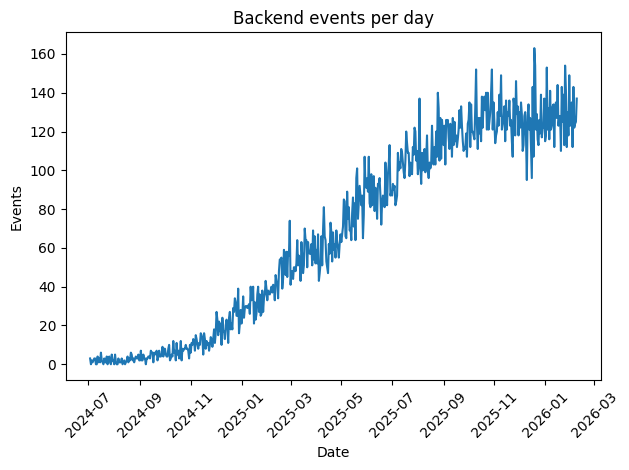

In [19]:
# Events per day
events_per_day = (
    be.dropna(subset=["event_timestamp"])
      .set_index("event_timestamp")
      .resample("D")
      .size()
      .rename("n_events")
      .reset_index()
)

plt.figure()
plt.plot(events_per_day["event_timestamp"], events_per_day["n_events"])
plt.title("Backend events per day")
plt.xlabel("Date")
plt.ylabel("Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


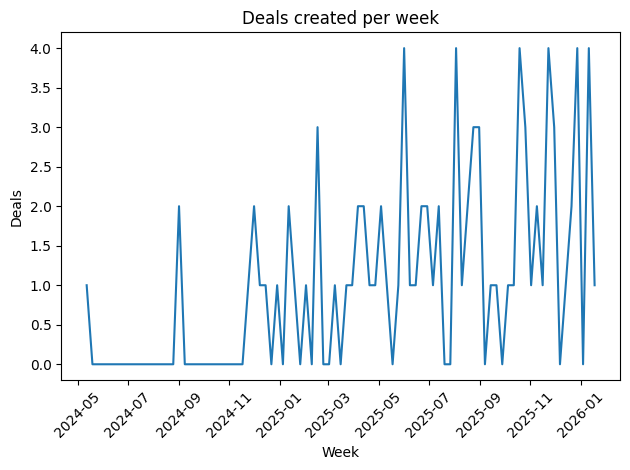

In [20]:
# Deals created per week
deals_created_per_week = (
    dl.dropna(subset=["create_date"])
      .set_index("create_date")
      .resample("W")
      .size()
      .rename("n_deals_created")
      .reset_index()
)

plt.figure()
plt.plot(deals_created_per_week["create_date"], deals_created_per_week["n_deals_created"])
plt.title("Deals created per week")
plt.xlabel("Week")
plt.ylabel("Deals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


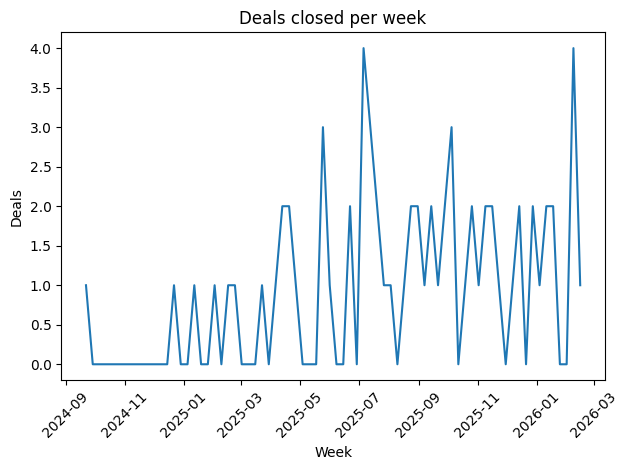

In [21]:
# Deals closed per week (close_date)
deals_closed_per_week = (
    dl.dropna(subset=["close_date"])
      .set_index("close_date")
      .resample("W")
      .size()
      .rename("n_deals_closed")
      .reset_index()
)

plt.figure()
plt.plot(deals_closed_per_week["close_date"], deals_closed_per_week["n_deals_closed"])
plt.title("Deals closed per week")
plt.xlabel("Week")
plt.ylabel("Deals")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 ## 4) Category distributions

 - Top event names

 - Deal pipelines, deal types

 - Contacts by lifecycle stage

 - Orgs by country/industry

In [22]:
# Top event names
top_events = (
    be["event_name"]
    .fillna("<<NULL>>")
    .value_counts()
    .head(30)
    .reset_index()
)
top_events.columns = ["event_name", "count"]
top_events


,event_name,count
0,TokenGenerated,11989
1,SearchExecuted,9969
2,SearchResultAppraised,8206
3,SearchUpdated,3240
4,SearchResultFullTextAppraised,2022
5,SearchCreated,1191
6,SearchExported,973
7,LabelCreated,599
8,LabelUpdated,386
9,LabelDeleted,225


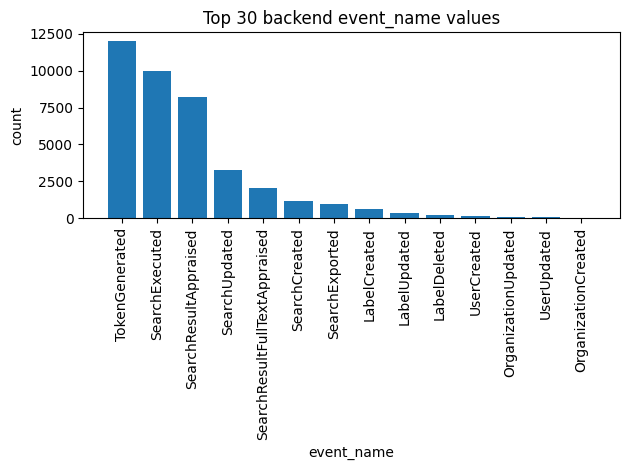

In [23]:
plt.figure()
plt.bar(top_events["event_name"], top_events["count"])
plt.title("Top 30 backend event_name values")
plt.xlabel("event_name")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [24]:
# Deal pipeline distribution
pipeline_dist = dl["pipeline"].fillna("<<NULL>>").value_counts().reset_index()
pipeline_dist.columns = ["pipeline", "count"]
pipeline_dist


,pipeline,count
0,Sales Pipeline,89


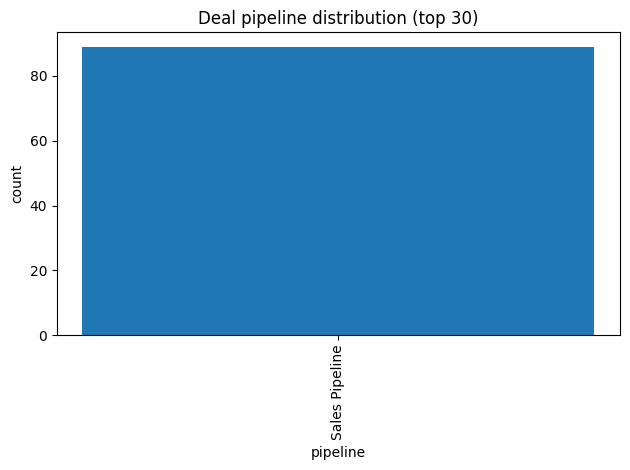

In [25]:
plt.figure()
plt.bar(pipeline_dist["pipeline"].head(30), pipeline_dist["count"].head(30))
plt.title("Deal pipeline distribution (top 30)")
plt.xlabel("pipeline")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [26]:
# Deal type distribution
deal_type_dist = dl["deal_type"].fillna("<<NULL>>").value_counts().reset_index()
deal_type_dist.columns = ["deal_type", "count"]
deal_type_dist.head(30)


,deal_type,count
0,newbusiness,78
1,existing_business,11


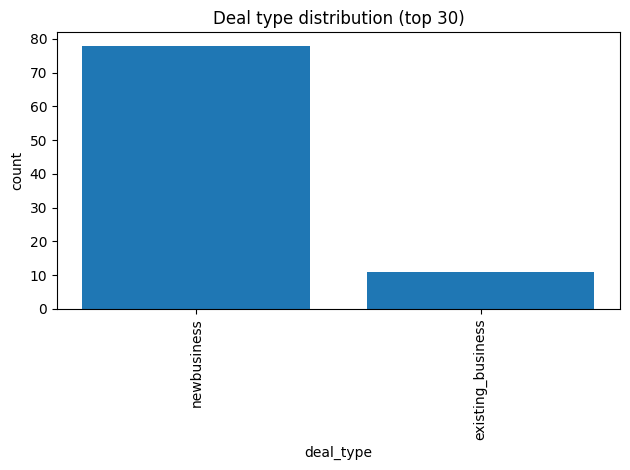

In [27]:
plt.figure()
plt.bar(deal_type_dist["deal_type"].head(30), deal_type_dist["count"].head(30))
plt.title("Deal type distribution (top 30)")
plt.xlabel("deal_type")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [28]:
# Contacts lifecycle stage distribution
lifecycle_dist = ct["lifecycle_stage"].fillna("<<NULL>>").value_counts().reset_index()
lifecycle_dist.columns = ["lifecycle_stage", "count"]
lifecycle_dist


,lifecycle_stage,count
0,lead,315
1,customer,137
2,opportunity,37


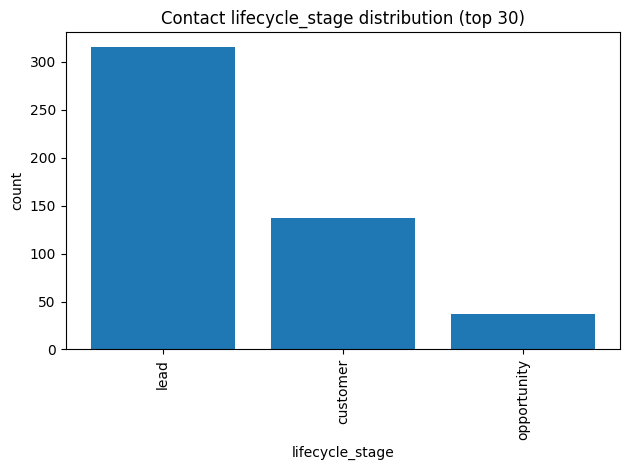

In [29]:
plt.figure()
plt.bar(lifecycle_dist["lifecycle_stage"].head(30), lifecycle_dist["count"].head(30))
plt.title("Contact lifecycle_stage distribution (top 30)")
plt.xlabel("lifecycle_stage")
plt.ylabel("count")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [30]:
# Orgs by country and industry
country_dist = org["country"].fillna("<<NULL>>").value_counts().head(30).reset_index()
country_dist.columns = ["country", "count"]

industry_dist = org["industry"].fillna("<<NULL>>").value_counts().head(30).reset_index()
industry_dist.columns = ["industry", "count"]

display(country_dist)
display(industry_dist)


,country,count
0,Germany,40
1,United Kingdom,25
2,Austria,20
3,Switzerland,19
4,United States,18
5,Norway,16
6,Belgium,14
7,Sweden,14
8,Ireland,14
9,Italy,13


,industry,count
0,Healthcare IT,23
1,Biotechnology,19
2,Diagnostics,18
3,Neurology,18
4,Prosthetics,18
5,Ophthalmology,17
6,Regulatory Consulting,16
7,Imaging,16
8,Dental,13
9,Pharmaceuticals,13


 ## 5) Numeric cleanup and distributions

 `number_of_employees` is a string in the export; we attempt to coerce it into a numeric field.

In [31]:
def coerce_int_series(s: pd.Series) -> pd.Series:
    """
    Coerce a series to integer where possible by extracting digits.
    Keeps NA where conversion fails.
    """
    if s.dtype.name in ("Int64", "int64"):
        return s
    cleaned = (
        s.astype("string")
         .str.replace(r"[^\d]", "", regex=True)
         .replace("", pd.NA)
    )
    return pd.to_numeric(cleaned, errors="coerce").astype("Int64")

org["employees_int"] = coerce_int_series(org["number_of_employees"])

org[["number_of_employees", "employees_int"]].head(10)


,number_of_employees,employees_int
0,11-50,1150
1,501-1000,5011000
2,501-1000,5011000
3,11-50,1150
4,11-50,1150
5,51-200,51200
6,51-200,51200
7,1-10,110
8,11-50,1150
9,11-50,1150


In [32]:
# Employee count stats
org["employees_int"].describe()


count             253.0
mean     2695199.960474
std      3822549.809143
min               110.0
25%              1150.0
50%            201500.0
75%           5011000.0
max          10015000.0
Name: employees_int, dtype: Float64

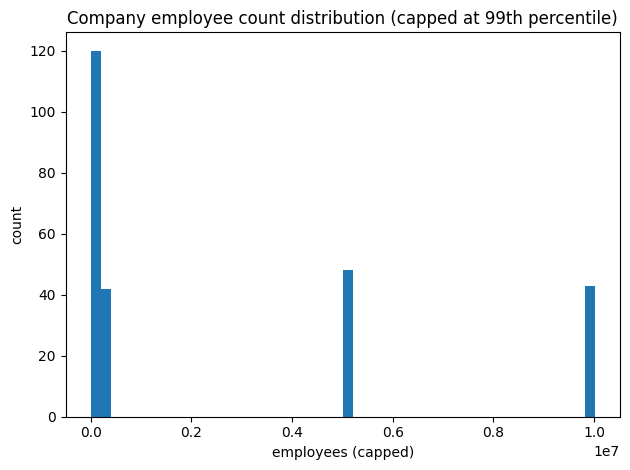

In [33]:
# Plot employee distribution (cap extremes for readability)
emp = org["employees_int"].dropna()
if len(emp) > 0:
    cap = emp.quantile(0.99)
    emp_capped = emp.clip(upper=cap)

    plt.figure()
    plt.hist(emp_capped, bins=50)
    plt.title("Company employee count distribution (capped at 99th percentile)")
    plt.xlabel("employees (capped)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


In [34]:
# Deal amount distribution
amount = dl["amount"].dropna()
if len(amount) > 0:
    cap = amount.quantile(0.99)
    amount_capped = amount.clip(upper=cap)

    plt.figure()
    plt.hist(amount_capped, bins=50)
    plt.title("Deal amount distribution (capped at 99th percentile)")
    plt.xlabel("amount (capped)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


TypeError: Invalid value '28000.000000000113' for dtype 'Int64'

 ## 6) Relationship coverage and join quality checks



 We validate how well the HubSpot tables connect via `hubspot_company_id` / `company_id`,

 and how backend `organization_id` overlaps (if at all) with HubSpot IDs (often they do not match).

In [35]:
# Deals -> Org join coverage
deals_with_company = dl["hubspot_company_id"].notna().sum()
matched_org_for_deals = dl.merge(org[["company_id"]], left_on="hubspot_company_id", right_on="company_id", how="inner")["deal_id"].nunique()

pd.DataFrame([{
    "metric": "deals_with_company_id",
    "value": int(deals_with_company),
}, {
    "metric": "unique_deals_matching_org",
    "value": int(matched_org_for_deals),
}])


,metric,value
0,deals_with_company_id,89
1,unique_deals_matching_org,89


In [36]:
# Contacts -> Org join coverage
contacts_with_company = ct["hubspot_company_id"].notna().sum()
matched_org_for_contacts = ct.merge(org[["company_id"]], left_on="hubspot_company_id", right_on="company_id", how="inner")["contact_id"].nunique()

pd.DataFrame([{
    "metric": "contacts_with_company_id",
    "value": int(contacts_with_company),
}, {
    "metric": "unique_contacts_matching_org",
    "value": int(matched_org_for_contacts),
}])


,metric,value
0,contacts_with_company_id,489
1,unique_contacts_matching_org,489


In [37]:
# Contacts -> Deals overlap by company_id (how many companies have both contacts and deals)
companies_with_deals = set(dl["hubspot_company_id"].dropna().unique())
companies_with_contacts = set(ct["hubspot_company_id"].dropna().unique())

pd.DataFrame([{
    "metric": "companies_with_deals",
    "value": int(len(companies_with_deals)),
}, {
    "metric": "companies_with_contacts",
    "value": int(len(companies_with_contacts)),
}, {
    "metric": "companies_with_both",
    "value": int(len(companies_with_deals & companies_with_contacts)),
}])


,metric,value
0,companies_with_deals,78
1,companies_with_contacts,253
2,companies_with_both,78


In [38]:
# backend_events org_id vs hubspot company_id overlap (often zero unless explicitly mapped)
backend_orgs = set(be["organization_id"].dropna().unique())
hubspot_company_ids = set(org["company_id"].dropna().astype("Int64").astype("int64", errors="ignore") if False else org["company_id"].dropna().unique())

# Note: types differ (backend org IDs are strings). We compare string representations.
hubspot_company_ids_str = set(map(str, hubspot_company_ids))
overlap = backend_orgs & hubspot_company_ids_str

pd.DataFrame([{
    "metric": "unique_backend_organization_id",
    "value": int(len(backend_orgs)),
}, {
    "metric": "unique_hubspot_company_id",
    "value": int(len(hubspot_company_ids_str)),
}, {
    "metric": "overlap_backend_org_vs_hubspot_company_id_as_str",
    "value": int(len(overlap)),
}])


,metric,value
0,unique_backend_organization_id,37
1,unique_hubspot_company_id,253
2,overlap_backend_org_vs_hubspot_company_id_as_str,0


 ## 7) Event activity per user/org

 Identify top users and orgs by event volume, plus concentration metrics.

In [39]:
top_users = (
    be["user_id"].fillna("<<NULL>>")
      .value_counts()
      .head(30)
      .reset_index()
)
top_users.columns = ["user_id", "n_events"]
top_users


,user_id,n_events
0,68a076db-98ee-42aa-9354-074dc3457351,1169
1,4f8447e2-956f-4a01-aa21-180cfc831f62,1095
2,d522461e-8e3a-406d-8c14-acfe8b3276af,1053
3,0b86a598-f8a4-4edc-8f44-c24e902df777,1011
4,d3b3c1f0-23f9-4943-a8cc-a25cca3dbf28,997
5,f7e158b5-107a-4a33-9f70-f83fad590169,991
6,40ec0118-aac7-4b7d-aeb3-d9cc79f74c29,964
7,146dda75-703c-462b-9038-235415c6b85e,964
8,cdcf1366-0682-4865-bab1-44099f313161,940
9,bf11452e-af35-4496-bfdc-75fc25e0ced8,936


In [40]:
top_orgs = (
    be["organization_id"].fillna("<<NULL>>")
      .value_counts()
      .head(30)
      .reset_index()
)
top_orgs.columns = ["organization_id", "n_events"]
top_orgs


,organization_id,n_events
0,ed31a0a1-1ffc-4ef6-aa35-12645225338e,4086
1,1dedfc50-1e5b-4624-8fd1-c689de270bbc,3704
2,ee58d325-cae4-422f-b359-90dbcba18cb3,2826
3,cc55b936-0090-41a1-a09d-6e3ba637c0a6,2705
4,8fc5002e-4c09-4169-8df5-4d9a950961d3,2653
5,ee6d01c8-f3c8-49e5-9b27-9540f7fc7c37,2172
6,839ec0f5-7c99-48ca-9a57-305028d7fa03,1965
7,84ef39a8-5176-4c57-b3fc-4e49ffca3890,1892
8,a7e01074-ebc8-4820-9bcd-00e14ffbde63,1713
9,3c08f8f7-d293-4a5c-acfe-88ebc9de21d5,1643


In [41]:
# Concentration: what % of events come from top N orgs/users
def concentration_share(series: pd.Series, top_n: int = 10) -> float:
    vc = series.value_counts(dropna=False)
    if vc.sum() == 0:
        return np.nan
    return float(vc.head(top_n).sum() / vc.sum())

pd.DataFrame([
    {"metric": "share_events_top10_orgs", "value": concentration_share(be["organization_id"], 10)},
    {"metric": "share_events_top50_orgs", "value": concentration_share(be["organization_id"], 50)},
    {"metric": "share_events_top10_users", "value": concentration_share(be["user_id"], 10)},
    {"metric": "share_events_top50_users", "value": concentration_share(be["user_id"], 50)},
])


,metric,value
0,share_events_top10_orgs,0.646814
1,share_events_top50_orgs,1.000000
2,share_events_top10_users,0.258124
3,share_events_top50_users,0.750344


 ## 8) Attempt to parse `event_properties` (JSON) and extract common keys



 `event_properties` is stored as a string. We try:

 1) `json.loads` (valid JSON)

 2) a light cleanup for common patterns (single quotes, trailing commas) and retry



 We then compute the most common keys and optionally flatten a few of them.

In [42]:
def try_parse_json(s: str) -> dict | None:
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return None
    if not isinstance(s, str):
        s = str(s)

    s = s.strip()
    if s == "" or s.lower() in ("null", "none", "nan"):
        return None

    # First attempt: strict JSON
    try:
        obj = json.loads(s)
        return obj if isinstance(obj, dict) else None
    except Exception:
        pass

    # Second attempt: common non-JSON patterns
    # - replace single quotes with double quotes (risky, but often works)
    # - remove trailing commas before } or ]
    s2 = s
    s2 = re.sub(r",\s*([}\]])", r"\1", s2)
    if "'" in s2 and '"' not in s2:
        s2 = s2.replace("'", '"')

    try:
        obj = json.loads(s2)
        return obj if isinstance(obj, dict) else None
    except Exception:
        return None


In [43]:
# Parse a sample first to avoid heavy work on huge datasets
sample_n = min(2000, len(be))
parsed_sample = be["event_properties"].head(sample_n).apply(try_parse_json)

parse_rate = parsed_sample.notna().mean()
parse_rate


np.float64(1.0)

In [44]:
# Collect key frequencies from the sample
key_counts = {}
for d in parsed_sample.dropna():
    for k in d.keys():
        key_counts[k] = key_counts.get(k, 0) + 1

top_keys = (
    pd.DataFrame([{"key": k, "count": v} for k, v in key_counts.items()])
      .sort_values("count", ascending=False)
      .head(40)
)
top_keys


,key,count
0,user,2000
1,organization,2000
2,search,1266
3,search_result,495
4,label,50


In [45]:
# If parse_rate is decent, parse the whole column (can be slow if dataset is large)
# You can keep it commented and only parse selectively.
# be["event_props_dict"] = be["event_properties"].apply(try_parse_json)


 ## 9) Deals stage-timing analysis

 We analyze the time gaps between stage entry timestamps (where available).

In [46]:
stage_cols = [
    "date_entered_pre_pitch",
    "date_entered_pitching",
    "date_entered_product_testing",
    "date_entered_price_offering",
    "date_entered_contract_negotiation",
    "date_entered_closed_won",
    "date_entered_closed_lost",
]

present_stage_cols = [c for c in stage_cols if c in dl.columns]
present_stage_cols


['date_entered_pre_pitch',
 'date_entered_pitching',
 'date_entered_product_testing',
 'date_entered_price_offering',
 'date_entered_contract_negotiation',
 'date_entered_closed_won',
 'date_entered_closed_lost']

In [47]:
# Compute duration between consecutive stage timestamps (in days)
timing = dl[["deal_id"] + present_stage_cols].copy()
for i in range(len(present_stage_cols) - 1):
    a = present_stage_cols[i]
    b = present_stage_cols[i + 1]
    timing[f"days_{a}_to_{b}"] = (timing[b] - timing[a]).dt.total_seconds() / 86400

duration_cols = [c for c in timing.columns if c.startswith("days_")]
timing[duration_cols].describe()


,days_date_entered_pre_pitch_to_date_entered_pitching,days_date_entered_pitching_to_date_entered_product_testing,days_date_entered_product_testing_to_date_entered_price_offering,days_date_entered_price_offering_to_date_entered_contract_negotiation,days_date_entered_contract_negotiation_to_date_entered_closed_won,days_date_entered_closed_won_to_date_entered_closed_lost
count,57.000000,54.000000,42.000000,43.000000,22.000000,2.000000
mean,28.929825,19.555556,13.547619,11.279070,12.909091,128.097922
std,26.062329,19.583076,11.203663,11.112682,9.461245,2.689944
min,1.000000,2.000000,1.000000,1.000000,1.000000,126.195845
25%,7.000000,6.000000,4.250000,2.000000,6.250000,127.146884
50%,17.000000,10.500000,12.000000,5.000000,11.500000,128.097922
75%,54.000000,27.000000,21.750000,16.500000,19.000000,129.048961
max,99.000000,81.000000,52.000000,42.000000,35.000000,130.000000


In [48]:
# Overall sales cycle approximation: create_date -> close_date
if "create_date" in dl.columns and "close_date" in dl.columns:
    dl["sales_cycle_days"] = (dl["close_date"] - dl["create_date"]).dt.total_seconds() / 86400
    dl["sales_cycle_days"].describe()


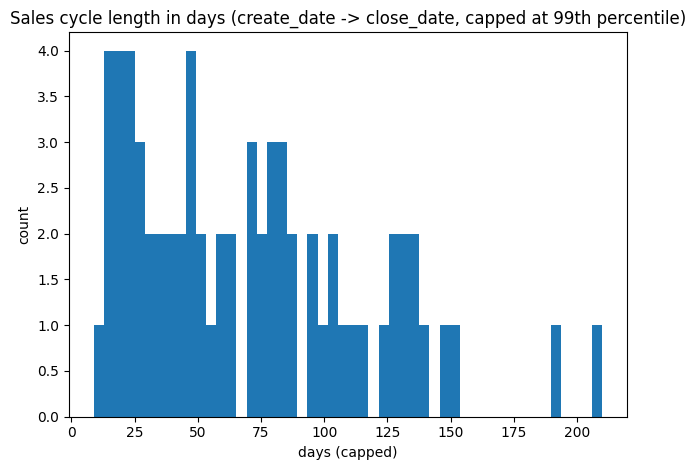

In [49]:
if "sales_cycle_days" in dl.columns and dl["sales_cycle_days"].notna().any():
    sc = dl["sales_cycle_days"].dropna()
    cap = sc.quantile(0.99)
    sc_capped = sc.clip(upper=cap)

    plt.figure()
    plt.hist(sc_capped, bins=50)
    plt.title("Sales cycle length in days (create_date -> close_date, capped at 99th percentile)")
    plt.xlabel("days (capped)")
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()


 ## 10) Building simple company-level aggregates

 We create company-level metrics from HubSpot tables (deals + contacts) and merge them into one dataset.

In [50]:
# Deals per company
deals_by_company = (
    dl.dropna(subset=["hubspot_company_id"])
      .groupby("hubspot_company_id", as_index=False)
      .agg(
          n_deals=("deal_id", "nunique"),
          n_closed=("is_closed", lambda x: int(x.fillna(False).sum())),
          n_closed_won=("is_closed_won", lambda x: int(x.fillna(False).sum())),
          total_amount=("amount", lambda x: int(x.fillna(0).sum())),
          avg_amount=("amount", lambda x: float(x.dropna().mean()) if x.notna().any() else np.nan),
          min_deal_create=("create_date", "min"),
          max_deal_create=("create_date", "max"),
          min_deal_close=("close_date", "min"),
          max_deal_close=("close_date", "max"),
      )
)

deals_by_company.head()


,hubspot_company_id,n_deals,n_closed,n_closed_won,total_amount,avg_amount,min_deal_create,max_deal_create,min_deal_close,max_deal_close
0,1000000,2,1,1,20000,10000,2025-08-25 01:47:03,2025-10-22 20:02:47,2025-09-29 01:47:03,2025-09-29 01:47:03
1,1000106,2,2,2,17500,8750,2025-05-24 17:05:48,2025-12-20 17:05:48,2025-09-26 17:05:48,2026-01-06 17:05:48
2,1000379,1,1,1,8000,8000,2024-05-06 23:01:51,2024-05-06 23:01:51,2024-09-17 23:01:51,2024-09-17 23:01:51
3,1000486,2,1,1,22000,11000,2025-05-29 21:47:57,2025-11-14 20:59:39,2025-09-11 21:47:57,2025-09-11 21:47:57
4,1000636,1,1,1,20000,20000,2025-06-03 19:20:40,2025-06-03 19:20:40,2025-07-06 19:20:40,2025-07-06 19:20:40


In [51]:
# Contacts per company
contacts_by_company = (
    ct.dropna(subset=["hubspot_company_id"])
      .groupby("hubspot_company_id", as_index=False)
      .agg(
          n_contacts=("contact_id", "nunique"),
          n_emails=("email", lambda x: int(x.dropna().nunique())),
          lifecycle_stages=("lifecycle_stage", lambda x: ", ".join(sorted(set(map(str, x.dropna().unique()))))[:200]),
          min_contact_create=("create_date", "min"),
          max_contact_create=("create_date", "max"),
      )
)

contacts_by_company.head()


,hubspot_company_id,n_contacts,n_emails,lifecycle_stages,min_contact_create,max_contact_create
0,1000000,3,3,customer,2025-06-04 02:14:01,2025-10-10 15:20:33
1,1000106,3,3,customer,2025-06-30 04:32:42,2025-09-17 21:58:25
2,1000379,5,5,customer,2024-08-07 17:31:51,2025-01-07 00:25:45
3,1000486,4,4,customer,2025-06-30 16:55:33,2025-10-04 04:13:33
4,1000636,3,3,customer,2025-08-05 06:17:15,2025-11-18 00:59:04


In [52]:
# Company master dataset
company_master = (
    org.rename(columns={"company_id": "hubspot_company_id"})
       .merge(deals_by_company, on="hubspot_company_id", how="left")
       .merge(contacts_by_company, on="hubspot_company_id", how="left")
)

company_master.head()


,hubspot_company_id,company_name,domain,industry,country,number_of_employees,create_date,employees_int,n_deals,n_closed,n_closed_won,total_amount,avg_amount,min_deal_create,max_deal_create,min_deal_close,max_deal_close,n_contacts,n_emails,lifecycle_stages,min_contact_create,max_contact_create
0,1000000,Acumed ApS,acumed.com,Dental,Switzerland,11-50,2025-05-05 21:19:33,1150,2.0,1.0,1.0,20000,10000,2025-08-25 01:47:03,2025-10-22 20:02:47,2025-09-29 01:47:03,2025-09-29 01:47:03,3,3,customer,2025-06-04 02:14:01,2025-10-10 15:20:33
1,1000106,BioVance d.o.o.,biovance.com,Healthcare IT,Germany,501-1000,2025-05-05 11:38:37,5011000,2.0,2.0,2.0,17500,8750,2025-05-24 17:05:48,2025-12-20 17:05:48,2025-09-26 17:05:48,2026-01-06 17:05:48,3,3,customer,2025-06-30 04:32:42,2025-09-17 21:58:25
2,1000379,ClearPath S.A.,clearpath.com,Dental,Sweden,501-1000,2024-07-13 19:38:57,5011000,1.0,1.0,1.0,8000,8000,2024-05-06 23:01:51,2024-05-06 23:01:51,2024-09-17 23:01:51,2024-09-17 23:01:51,5,5,customer,2024-08-07 17:31:51,2025-01-07 00:25:45
3,1000486,DentalPro GmbH,dentalpro.co,Healthcare IT,United Kingdom,11-50,2025-04-24 05:18:11,1150,2.0,1.0,1.0,22000,11000,2025-05-29 21:47:57,2025-11-14 20:59:39,2025-09-11 21:47:57,2025-09-11 21:47:57,4,4,customer,2025-06-30 16:55:33,2025-10-04 04:13:33
4,1000636,EvoMed SAS,evomed.co,Medical Devices,Norway,11-50,2025-06-05 21:49:59,1150,1.0,1.0,1.0,20000,20000,2025-06-03 19:20:40,2025-06-03 19:20:40,2025-07-06 19:20:40,2025-07-06 19:20:40,3,3,customer,2025-08-05 06:17:15,2025-11-18 00:59:04


In [53]:
# Coverage report
coverage = pd.DataFrame([{
    "metric": "companies_total",
    "value": int(company_master["hubspot_company_id"].nunique(dropna=True)),
}, {
    "metric": "companies_with_deals",
    "value": int(company_master["n_deals"].notna().sum()),
}, {
    "metric": "companies_with_contacts",
    "value": int(company_master["n_contacts"].notna().sum()),
}, {
    "metric": "companies_with_both",
    "value": int(((company_master["n_deals"].notna()) & (company_master["n_contacts"].notna())).sum()),
}])
coverage


,metric,value
0,companies_total,253
1,companies_with_deals,78
2,companies_with_contacts,253
3,companies_with_both,78


 ## 11) Sanity checks: currency, amount, closed flags

 HubSpot exports sometimes contain inconsistent fields. We flag a few patterns.

In [54]:
sanity = []

# Closed-won implies closed (usually)
if "is_closed" in dl.columns and "is_closed_won" in dl.columns:
    incons = dl[(dl["is_closed_won"] == True) & (dl["is_closed"] != True)]
    sanity.append({"check": "closed_won_implies_closed", "violations": int(len(incons))})

# Amount missing on closed-won deals
if "amount" in dl.columns and "is_closed_won" in dl.columns:
    miss_amt = dl[(dl["is_closed_won"] == True) & (dl["amount"].isna())]
    sanity.append({"check": "closed_won_missing_amount", "violations": int(len(miss_amt))})

# Currency missing where amount exists
if "currency" in dl.columns and "amount" in dl.columns:
    miss_cur = dl[(dl["amount"].notna()) & (dl["currency"].isna())]
    sanity.append({"check": "amount_present_currency_missing", "violations": int(len(miss_cur))})

pd.DataFrame(sanity)


,check,violations
0,closed_won_implies_closed,0
1,closed_won_missing_amount,0
2,amount_present_currency_missing,0


 ## 12) Export useful intermediate artifacts (optional)

 You can persist company-level aggregates for further analysis.

In [ ]:
# Uncomment to save:
# OUT_DIR = REPO_ROOT / "eda_outputs"
# OUT_DIR.mkdir(exist_ok=True)
# company_master.to_csv(OUT_DIR / "company_master.csv", index=False)
# deals_by_company.to_csv(OUT_DIR / "deals_by_company.csv", index=False)
# contacts_by_company.to_csv(OUT_DIR / "contacts_by_company.csv", index=False)
# print("Saved outputs to:", OUT_DIR)


 ## 13) Next ideas (optional)

 - Add mapping between backend `organization_id` and HubSpot `hubspot_company_id` if you have it (domain-based matching is a common approach).

 - Parse and flatten `event_properties` into separate columns for the top keys.

 - Create product engagement metrics per org (MAU/WAU, retention cohorts, feature adoption) and compare with deal stages.